In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("research_grade_6g_synthetic_dataset_10000.csv")

ACTIVE_USERS = 50

df = df.sample(ACTIVE_USERS, random_state=42).reset_index(drop=True)

In [3]:
cols = [
    "Throughput_Mbps",
    "Latency_ms",
    "Energy_J",
    "Cost",
    "Allocated_BW_MHz"
]

scaler = MinMaxScaler()

df[cols] = scaler.fit_transform(df[cols])

In [4]:
POP_SIZE = 50

GENERATIONS = 100

CROSSOVER_RATE = 0.8

MUTATION_RATE = 0.1

ELITISM = 2

In [5]:
MAX_POWER = 20

TOTAL_BW = 100

TOTAL_RB = 275

MIN_SINR = 10

MAX_LATENCY = 10

In [7]:
def create_chromosome():

    chromosome=[]

    for _ in range(ACTIVE_USERS):

        chromosome.append(random.randint(1,8))          # Channel

        chromosome.append(random.choice([5,10,20,40]))  # BW

        chromosome.append(random.uniform(0.2,2.0))      # Power

    return chromosome

In [15]:
def fitness(chromosome):

    throughput = df["Throughput_Mbps"].mean()
    energy = df["Energy_J"].mean()
    latency = df["Latency_ms"].mean()
    cost = df["Cost"].mean()
    bandwidth = df["Allocated_BW_MHz"].mean()

    score = (
        0.35 * throughput
        - 0.25 * energy
        - 0.20 * latency
        - 0.10 * cost
        + 0.10 * bandwidth
    )

    # Constraint penalties
    penalty = 0

    if df["Tx_Power_W"].sum() > MAX_POWER:
        penalty += 100

    if df["Allocated_BW_MHz"].sum() > TOTAL_BW:
        penalty += 100

    if (df["SINR_dB"] < MIN_SINR).any():
        penalty += 100

    if (df["Latency_ms"] > MAX_LATENCY).any():
        penalty += 100

    return score - penalty

In [16]:
def tournament(population):

    k = 5

    selected = random.sample(population,k)

    selected.sort(
        key=fitness,
        reverse=True
    )

    return selected[0]

In [17]:
def crossover(parent1,parent2):

    point=random.randint(1,len(parent1)-1)

    child1=parent1[:point]+parent2[point:]

    child2=parent2[:point]+parent1[point:]

    return child1,child2

In [18]:
def mutate(child):

    for i in range(len(child)):

        if random.random()<MUTATION_RATE:

            if i%3==0:

                child[i]=random.randint(1,8)

            elif i%3==1:

                child[i]=random.choice([5,10,20,40])

            else:

                child[i]=random.uniform(0.2,2)

    return child

In [19]:
population=[create_chromosome() for _ in range(POP_SIZE)]

history=[]

for generation in range(GENERATIONS):

    population=sorted(
        population,
        key=fitness,
        reverse=True
    )

    history.append(fitness(population[0]))

    new_population=population[:ELITISM]

    while len(new_population)<POP_SIZE:

        p1=tournament(population)

        p2=tournament(population)

        c1,c2=crossover(p1,p2)

        c1=mutate(c1)

        c2=mutate(c2)

        new_population.extend([c1,c2])

    population=new_population[:POP_SIZE]

In [20]:
best=population[0]

print("Best Fitness =",fitness(best))

Best Fitness = -100.05028381245374


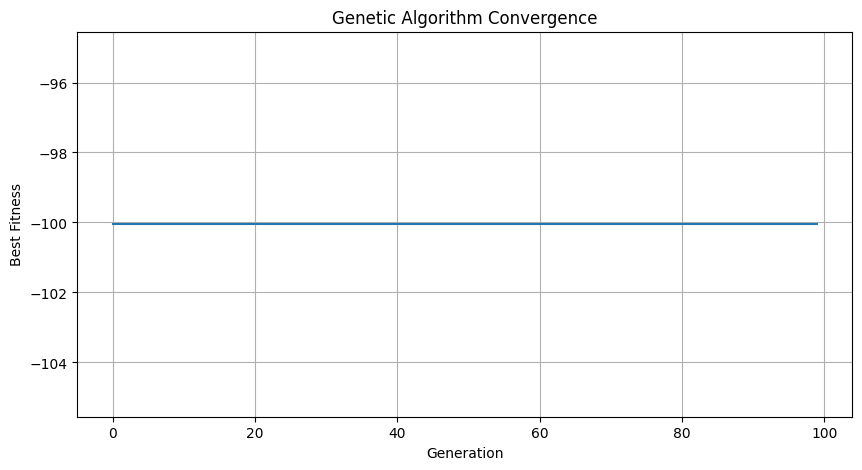

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history)

plt.xlabel("Generation")

plt.ylabel("Best Fitness")

plt.title("Genetic Algorithm Convergence")

plt.grid(True)

plt.show()